In [1]:
from irrigator.forecasts.arome_processing import (
    sync_static,
    sync_forecast,
    sync_dynamic,
    get_available_coverages,
    parse_coverage_id,
    find_available_run_dates,
    load_arome_daily_cache,
    ensure_dirs,
    DAILY_DIR,
    RAW_DIR,
)
from collections import defaultdict
import os

REPO_ROOT = os.path.dirname(os.getcwd())
os.chdir(REPO_ROOT)


results = sync_static(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

results_dyn = sync_dynamic(overwrite=False)


results = sync_forecast(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

    

2026-08-18 15:22:50,910 Syncing static archive...
2026-08-18 15:24:20,715 [static] 2026-08-17: 98 calls
2026-08-18 15:24:27,478 [static] arome_daily_2026-08-17.nc → 24.3 MB
2026-08-18 15:24:27,480 Sync complete: 5 available, 4 cached, 1 fetched, 0 errors
2026-08-18 15:24:27,481 Syncing dynamic archive...


  ✓ 2026-08-14: cached
  ✓ 2026-08-15: cached
  ✓ 2026-08-16: cached
  ↓ 2026-08-17: fetched
  ✓ 2026-08-18: cached


2026-08-18 15:24:47,313 [dynamic] 2026-08-18T09: done
2026-08-18 15:24:51,670 [dynamic] arome_daily_2026-08-14.nc → 8 windows, 24.1 MB
2026-08-18 15:24:56,042 [dynamic] arome_daily_2026-08-15.nc → 8 windows, 25.8 MB
2026-08-18 15:25:00,333 [dynamic] arome_daily_2026-08-16.nc → 8 windows, 24.4 MB
2026-08-18 15:25:04,628 [dynamic] arome_daily_2026-08-17.nc → 8 windows, 24.6 MB
2026-08-18 15:25:07,092 [dynamic] arome_daily_2026-08-18.nc → 4 windows, 23.3 MB
2026-08-18 15:25:07,095 Syncing forecast archive...
2026-08-18 15:27:41,140 [forecast] 2026-08-17: 194 calls
2026-08-18 15:27:49,155 [forecast] arome_daily_2026-08-17.nc → 48.0 MB
2026-08-18 15:29:06,358 Retry 1/4 for WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND___2 at 2026-08-18T05:00:00Z (HTTP 502, waiting 1s)
2026-08-18 15:30:39,886 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE at 2026-08-18T15:00:00Z (HTTP 502, waiting 1s)
2026-08-18 15:30:44,690 Retry 1/4 for DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE 

  ✓ 2026-08-14: cached
  ✓ 2026-08-15: cached
  ✓ 2026-08-16: cached
  ↓ 2026-08-17: fetched
  ↓ 2026-08-18: fetched


# IFS

In [2]:
import os
import logging
from datetime import date, timedelta
from pathlib import Path
from irrigator.ingestion.ifs_ens_client import run_ifs_pipeline, load_ifs_daily

# Today only (default)
# daily_paths = run_ifs_pipeline()

# Or a date range:
daily_paths = run_ifs_pipeline(
    start=date(2026, 8, 5),
    end=date.today(),
    keep_raw=False,  # delete GRIBs after processing (default)
    #split_params=False
)

print(f"\nProcessed {len(daily_paths)} runs:")
for p in daily_paths:
    print(f"  {p.name}  ({p.stat().st_size / 1e6:.0f} MB)")


2026-08-18 13:51:29,561 IFS ENS 2026-08-05 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-05_00z.nc


2026-08-18 13:51:59,562 IFS ENS 2026-08-06 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-06_00z.nc
2026-08-18 13:52:29,564 IFS ENS 2026-08-07 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-07_00z.nc
2026-08-18 13:52:59,565 IFS ENS 2026-08-08 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-08_00z.nc
2026-08-18 13:53:29,566 IFS ENS 2026-08-09 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-09_00z.nc
2026-08-18 13:53:59,567 IFS ENS 2026-08-10 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-10_00z.nc
2026-08-18 13:54:29,569 IFS ENS 2026-08-11 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-11_00z.nc
2026-08-18 13:54:59,570 IFS ENS 2026-08-12 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-12_00z.nc
2026-08-18 13:55:29,572 IFS ENS 2026-08-13 00Z already processed: data/processed/ifs_ens/ifs_daily_2026-08-13_00z.nc
2026-08-18 13:55:59,575 IFS ENS 2026-08-14 00Z already processed

<multiple>:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

2026-08-18 14:24:42,460 Downloaded IFS ENS: data/raw/ifs_ens/ifs_ens_2026-08-17_00z.grib2 (17197.9 MB)
2026-08-18 14:24:42,461 [2026-08-17 00Z] Opening and slicing to bbox...


By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


2026-08-18 14:26:02,844 [2026-08-17 00Z] Processing to daily...
2026-08-18 14:33:22,989 IFS ENS daily: 16 days, 50 members, 8 variables
2026-08-18 14:33:24,809 Saved IFS ENS daily: data/processed/ifs_ens/ifs_daily_2026-08-17_00z.nc (48.2 MB, 50 members, 16 days)
2026-08-18 14:33:26,061 [2026-08-17 00Z] Deleted raw GRIB (17198 MB freed)
2026-08-18 14:33:56,072 [2026-08-18 00Z] Downloading...
2026-08-18 14:33:56,074 Downloading IFS ENS (bulk, source=ecmwf): 2026-08-18 00Z, 61 steps, 7 params
2026-08-18 14:34:23,707 Downloading <multiple>


<multiple>:   0%|          | 0.00/16.1G [00:00<?, ?B/s]

2026-08-18 15:00:16,376 Downloaded IFS ENS: data/raw/ifs_ens/ifs_ens_2026-08-18_00z.grib2 (17249.8 MB)
2026-08-18 15:00:16,377 [2026-08-18 00Z] Opening and slicing to bbox...
2026-08-18 15:01:41,270 [2026-08-18 00Z] Processing to daily...
2026-08-18 15:08:49,562 IFS ENS daily: 16 days, 50 members, 8 variables
2026-08-18 15:08:51,405 Saved IFS ENS daily: data/processed/ifs_ens/ifs_daily_2026-08-18_00z.nc (48.3 MB, 50 members, 16 days)
2026-08-18 15:08:52,282 [2026-08-18 00Z] Deleted raw GRIB (17250 MB freed)
2026-08-18 15:08:52,295 IFS pipeline complete: 14/14 runs processed



Processed 14 runs:
  ifs_daily_2026-08-05_00z.nc  (46 MB)
  ifs_daily_2026-08-06_00z.nc  (46 MB)
  ifs_daily_2026-08-07_00z.nc  (46 MB)
  ifs_daily_2026-08-08_00z.nc  (46 MB)
  ifs_daily_2026-08-09_00z.nc  (46 MB)
  ifs_daily_2026-08-10_00z.nc  (46 MB)
  ifs_daily_2026-08-11_00z.nc  (47 MB)
  ifs_daily_2026-08-12_00z.nc  (47 MB)
  ifs_daily_2026-08-13_00z.nc  (47 MB)
  ifs_daily_2026-08-14_00z.nc  (47 MB)
  ifs_daily_2026-08-15_00z.nc  (48 MB)
  ifs_daily_2026-08-16_00z.nc  (48 MB)
  ifs_daily_2026-08-17_00z.nc  (48 MB)
  ifs_daily_2026-08-18_00z.nc  (48 MB)


# SEAS5 hindcast archive (one-time per initialization month)

The seasonal bias correction needs the ECMWF SEAS5 1993–2016 retrospective
forecasts for the same initialization month as the operational forecast. The
download is intentionally opt-in because it is a sizeable one-time archive.

You also need processed France-wide ERA5-Land daily files covering the historical
period used for analog matching; the new PCA code reads those annual files lazily.

In [ ]:
from datetime import date
from irrigator.ingestion.cds_client import fetch_seas5_hindcasts

RUN_SEAS5_HINDCAST_ARCHIVE = True
SEAS5_INIT_MONTH = date.today().month

if RUN_SEAS5_HINDCAST_ARCHIVE:
    paths = fetch_seas5_hindcasts(
        init_month=SEAS5_INIT_MONTH,
        start_year=1993,
        end_year=2016,
        raw_dir=Path("data/raw"),
        overwrite=False,
    )
    print(f"SEAS5 hindcasts ready: {len(paths)} initialization files")
else:
    print("SEAS5 hindcast archive skipped. Set RUN_SEAS5_HINDCAST_ARCHIVE=True once when needed.")


In [10]:
from irrigator.ingestion.cds_client import (
    _seas5_output_path,
    FRANCE_BBOX,
    DEFAULT_RAW_DIR,
    BBoxWGS84,
)

from pathlib import Path
from datetime import date

import numpy as np
import xarray as xr
from irrigator.ingestion.cds_client import (
    _seas5_output_path,
    FRANCE_BBOX,
    DEFAULT_RAW_DIR,
    BBoxWGS84,
)
from pathlib import Path
import xarray as xr

from datetime import date
import numpy as np


def date_to_datetime64(d: date) -> np.datetime64:
    return np.datetime64(d, "ns")


def convert_seas5_monthly_accumulations(ds: xr.Dataset) -> xr.Dataset:
    """Convert SEAS5 monthly mean rates/fluxes to monthly accumulations.

    Converts
    --------
    tprate : m s-1
        -> tp : m accumulated over the forecast month

    msdsrf : W m-2
        -> ssrd : J m-2 accumulated over the forecast month

    The actual forecast month is determined from:
        forecast_reference_time + (forecastMonth - 1) months

    Thus the conversion automatically accounts for:
    - 28, 29, 30 and 31-day months
    - leap years
    - year transitions
    """

    

    seconds_in_day =  24 * 60 * 60

    # DataArray so xarray automatically broadcasts over
    # number / latitude / longitude



    # m s-1 -> m month-1
    ds["tp"] = ds["tprate"] * seconds_in_day
    ds["tp"].attrs = ds["tprate"].attrs.copy()
    ds["tp"].attrs.update(
        {
            "long_name": "Average daily Total precipitation accumulated over forecast month",
            "units": "m",
        }
    )

    # m s-1 -> m month-1
    ds["e"] = ds["erate"] * seconds_in_day
    ds["e"].attrs = ds["erate"].attrs.copy()
    ds["e"].attrs.update(
        {
            "long_name": "Average daily Total evaporation over forecast month",
            "units": "m",
        }
    )

    # W m-2 = J s-1 m-2 -> J m-2 month-1
    ds["ssrd"] = ds["msdsrf"] * seconds_in_day
    ds["ssrd"].attrs = ds["msdsrf"].attrs.copy()
    ds["ssrd"].attrs.update(
        {
            "long_name": ("Average daily Surface solar radiation downwards accumulated over forecast month"),
            "units": "J m-2",
        }
    )

    # Original rates no longer needed
    ds = ds.drop_vars(["tprate", "msdsrf"])
    ds = ds.rename({"mx2t24" : "t2m_max", "mn2t24" : "t2m_min"})

    return ds

def fetch_seas5(
    year: int,
    month: int,
    ref_file: str,
    *,
    bounding_box: BBoxWGS84 = FRANCE_BBOX,
    raw_dir: str | Path = DEFAULT_RAW_DIR,
) -> Path:

    raw_dir = Path(raw_dir)
    out_path = _seas5_output_path(raw_dir, year, month)

    ds_ref = xr.open_dataset(ref_file)

    ds_ref = ds_ref.sel(
        forecast_reference_time=date_to_datetime64(date(year, month, 1)),
        longitude=slice(
            bounding_box.west,
            bounding_box.east,
        ),
        latitude=slice(
            bounding_box.north,
            bounding_box.south,
        ),
    )

    # Correct monthly accumulation conversion
    ds_ref = convert_seas5_monthly_accumulations(ds_ref)

    ds_ref.to_netcdf(out_path)

    return out_path


In [11]:
for archive in [1,2,3,4]:
    ref_file = f"/home/mbaldacchino/data/seas5_archive_{str(archive)}.nc"
    for year in range(1993, 2027):
        for month in range(1, 13):
            try:
                out_path = fetch_seas5(year, month, ref_file=ref_file)
                print(f"Downloaded SEAS5 {year}-{month:02d} to {out_path}")
            except: 
                continue

Downloaded SEAS5 1993-01 to data/raw/seas5/seas5_1993_01.nc
Downloaded SEAS5 1993-02 to data/raw/seas5/seas5_1993_02.nc
Downloaded SEAS5 1993-03 to data/raw/seas5/seas5_1993_03.nc
Downloaded SEAS5 1993-04 to data/raw/seas5/seas5_1993_04.nc
Downloaded SEAS5 1993-05 to data/raw/seas5/seas5_1993_05.nc
Downloaded SEAS5 1993-06 to data/raw/seas5/seas5_1993_06.nc
Downloaded SEAS5 1993-07 to data/raw/seas5/seas5_1993_07.nc
Downloaded SEAS5 1993-08 to data/raw/seas5/seas5_1993_08.nc
Downloaded SEAS5 1993-09 to data/raw/seas5/seas5_1993_09.nc
Downloaded SEAS5 1993-10 to data/raw/seas5/seas5_1993_10.nc
Downloaded SEAS5 1993-11 to data/raw/seas5/seas5_1993_11.nc
Downloaded SEAS5 1993-12 to data/raw/seas5/seas5_1993_12.nc
Downloaded SEAS5 1994-01 to data/raw/seas5/seas5_1994_01.nc
Downloaded SEAS5 1994-02 to data/raw/seas5/seas5_1994_02.nc
Downloaded SEAS5 1994-03 to data/raw/seas5/seas5_1994_03.nc
Downloaded SEAS5 1994-04 to data/raw/seas5/seas5_1994_04.nc
Downloaded SEAS5 1994-05 to data/raw/sea

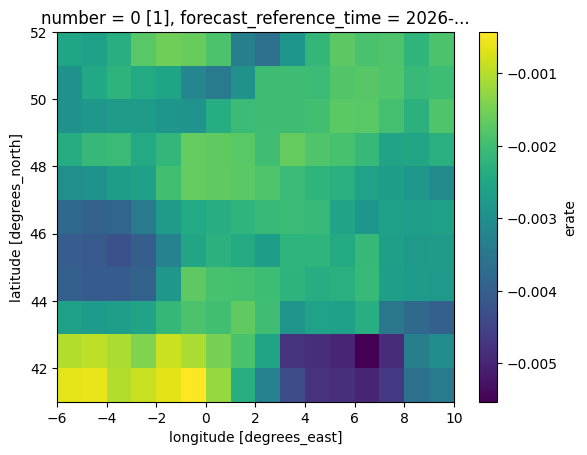

In [7]:
import xarray as xr 
(xr.open_dataset("/home/mbaldacchino/code/IrriGator/data/raw/seas5/seas5_2026_08.nc").erate.isel(number=0, forecastMonth=0)*86400).plot()

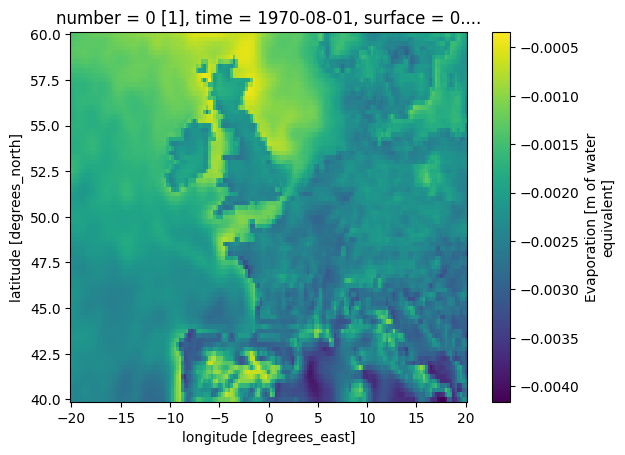

In [9]:
xr.open_dataset("/home/mbaldacchino/code/IrriGator/data/raw/era5_candidates/era5_monthly_1970_2026.nc").e.isel(time=7).plot()